In [1]:
%%capture
!pip install xgboost lightgbm scikit-learn pandas numpy scipy

In [2]:
from __future__ import annotations

import os
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
print('All imports successful!')

All imports successful!


In [3]:
# CONFIGURATION

if os.path.exists('/kaggle/input'):
    DATA_DIR = '/kaggle/input/competitions/march-machine-learning-mania-2026'
    OUTPUT_DIR = '/kaggle/working'
else:
    DATA_DIR = './data'
    OUTPUT_DIR = '.'

CURRENT_SEASON = 2026
MIN_TRAIN_SEASON = 2003

ELO_K = 20
ELO_INIT = 1500
ELO_HCA = 100
ELO_MOV_FACTOR = True

ENSEMBLE_WEIGHTS = (0.40, 0.40, 0.20)
SEED = 42

print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Data directory: /kaggle/input/competitions/march-machine-learning-mania-2026
Output directory: /kaggle/working


In [4]:
def _safe_read(name):
    path = os.path.join(DATA_DIR, name)
    if os.path.exists(path):
        return pd.read_csv(path)
    print(f'  {name} not found - skipping')
    return None


def load_all_data():
    print('Loading data ...')
    data = {}
    data['m_teams']          = _safe_read('MTeams.csv')
    data['w_teams']          = _safe_read('WTeams.csv')
    data['m_regular']        = _safe_read('MRegularSeasonCompactResults.csv')
    data['w_regular']        = _safe_read('WRegularSeasonCompactResults.csv')
    data['m_tourney']        = _safe_read('MNCAATourneyCompactResults.csv')
    data['w_tourney']        = _safe_read('WNCAATourneyCompactResults.csv')
    data['m_seeds']          = _safe_read('MNCAATourneySeeds.csv')
    data['w_seeds']          = _safe_read('WNCAATourneySeeds.csv')
    data['m_regular_detail'] = _safe_read('MRegularSeasonDetailedResults.csv')
    data['w_regular_detail'] = _safe_read('WRegularSeasonDetailedResults.csv')
    data['m_ordinals']       = _safe_read('MMasseyOrdinals.csv')
    data['w_ordinals']       = _safe_read('WMasseyOrdinals.csv')
    data['m_team_conf']      = _safe_read('MTeamConferences.csv')
    data['w_team_conf']      = _safe_read('WTeamConferences.csv')
    data['sample_sub']       = _safe_read('SampleSubmissionStage2.csv')
    if data['sample_sub'] is None:
        data['sample_sub']   = _safe_read('SampleSubmission.csv')
    loaded = [k for k, v in data.items() if v is not None]
    print(f'  Loaded {len(loaded)} datasets: {", ".join(loaded)}')
    return data


DATA = load_all_data()

Loading data ...
  WMasseyOrdinals.csv not found - skipping
  Loaded 14 datasets: m_teams, w_teams, m_regular, w_regular, m_tourney, w_tourney, m_seeds, w_seeds, m_regular_detail, w_regular_detail, m_ordinals, m_team_conf, w_team_conf, sample_sub


In [5]:
def _elo_k_mov(mov, elo_diff):
    """Margin-of-victory multiplier (FiveThirtyEight style)."""
    return max(1.0, np.log(abs(mov) + 1.0)) * (2.2 / ((elo_diff * 0.001) + 2.2))


def compute_elo(regular_df, tourney_df, k=ELO_K, init=ELO_INIT, hca=ELO_HCA, use_mov=ELO_MOV_FACTOR):
    """Run Elo over regular-season + tournament games.
    Returns {(season, team_id): elo_at_end_of_season}.
    """
    elo = {}
    season_elos = {}
    all_games = pd.concat([regular_df, tourney_df]).sort_values(['Season', 'DayNum'])
    prev_season = None

    for _, row in all_games.iterrows():
        season = int(row['Season'])

        # Between-season mean regression
        if season != prev_season and prev_season is not None:
            for tid, r in elo.items():
                season_elos[(prev_season, tid)] = r
            elo = {tid: 0.75 * r + 0.25 * init for tid, r in elo.items()}
        prev_season = season

        w_id, l_id = int(row['WTeamID']), int(row['LTeamID'])
        w_elo = elo.get(w_id, init)
        l_elo = elo.get(l_id, init)

        # Home-court adjustment
        w_loc = row.get('WLoc', 'N')
        w_adj = w_elo + (hca if w_loc == 'H' else (-hca if w_loc == 'A' else 0))

        # Expected win probability
        exp_w = 1.0 / (1.0 + 10 ** ((l_elo - w_adj) / 400.0))

        # Margin-of-victory adjusted K
        if use_mov and 'WScore' in row.index and 'LScore' in row.index:
            mov = int(row['WScore']) - int(row['LScore'])
            k_adj = k * _elo_k_mov(mov, w_adj - l_elo)
        else:
            k_adj = k

        elo[w_id] = w_elo + k_adj * (1.0 - exp_w)
        elo[l_id] = l_elo + k_adj * (0.0 - (1.0 - exp_w))

    if prev_season is not None:
        for tid, r in elo.items():
            season_elos[(prev_season, tid)] = r

    return season_elos


print('Computing Elo ratings (margin-of-victory adjusted) ...')
elo_m = compute_elo(DATA['m_regular'], DATA['m_tourney'])
elo_w = compute_elo(DATA['w_regular'], DATA['w_tourney'])
ELO_MAP = {**elo_m, **elo_w}
print(f'  {len(ELO_MAP):,} team-season Elo ratings computed')

Computing Elo ratings (margin-of-victory adjusted) ...
  24,158 team-season Elo ratings computed


In [6]:
def parse_seed(seed_str):
    """'W01' -> 1, 'X16a' -> 16."""
    return int(seed_str[1:3])


def build_seed_map(m_seeds, w_seeds):
    seed_map = {}
    for df in [m_seeds, w_seeds]:
        if df is None:
            continue
        for _, row in df.iterrows():
            seed_map[(int(row['Season']), int(row['TeamID']))] = parse_seed(row['Seed'])
    return seed_map


SEED_MAP = build_seed_map(DATA['m_seeds'], DATA['w_seeds'])
print(f'{len(SEED_MAP):,} seed entries')

4,506 seed entries


In [7]:
def _compute_possessions(row, prefix):
    opp = 'L' if prefix == 'W' else 'W'
    fga  = row.get(f'{prefix}FGA', 0)
    _or  = row.get(f'{prefix}OR',  0)
    to   = row.get(f'{prefix}TO',  0)
    fta  = row.get(f'{prefix}FTA', 0)
    ofga = row.get(f'{opp}FGA',    0)
    _oor = row.get(f'{opp}OR',     0)
    oto  = row.get(f'{opp}TO',     0)
    ofta = row.get(f'{opp}FTA',    0)
    return 0.5 * (
        (fga + 0.4*fta - 1.07*(_or / max(_or + row.get(f'{opp}DR', 1), 1)) * (fga - row.get(f'{prefix}FGM', 0)) + to)
        + (ofga + 0.4*ofta - 1.07*(_oor / max(_oor + row.get(f'{prefix}DR', 1), 1)) * (ofga - row.get(f'{opp}FGM', 0)) + oto)
    )


def compute_season_stats(detail_df):
    if detail_df is None:
        return None
    records = []
    for _, row in detail_df.iterrows():
        season = int(row['Season'])
        for is_winner in [True, False]:
            prefix = 'W' if is_winner else 'L'
            opp    = 'L' if is_winner else 'W'
            tid    = int(row[f'{prefix}TeamID'])
            poss   = max(_compute_possessions(row, prefix), 1)
            score     = row.get(f'{prefix}Score', 0)
            opp_score = row.get(f'{opp}Score',    0)
            records.append({
                'Season': season, 'TeamID': tid, 'Win': int(is_winner),
                'Score': score, 'OppScore': opp_score, 'Poss': poss,
                'OffEff':     score / poss * 100,
                'DefEff':     opp_score / poss * 100,
                'FGPct':      row.get(f'{prefix}FGM', 0) / max(row.get(f'{prefix}FGA', 1), 1),
                'FG3Pct':     row.get(f'{prefix}FGM3', 0) / max(row.get(f'{prefix}FGA3', 1), 1),
                'FTPct':      row.get(f'{prefix}FTM', 0) / max(row.get(f'{prefix}FTA', 1), 1),
                'ORPct':      row.get(f'{prefix}OR', 0) / max(row.get(f'{prefix}OR', 0) + row.get(f'{opp}DR', 1), 1),
                'DRPct':      row.get(f'{prefix}DR', 0) / max(row.get(f'{prefix}DR', 0) + row.get(f'{opp}OR', 1), 1),
                'AstToRatio': row.get(f'{prefix}Ast', 0) / max(row.get(f'{prefix}TO', 1), 1),
                'TO':  row.get(f'{prefix}TO',  0),
                'Stl': row.get(f'{prefix}Stl', 0),
                'Blk': row.get(f'{prefix}Blk', 0),
                'PF':  row.get(f'{prefix}PF',  0),
            })
    if not records:
        return None
    df = pd.DataFrame(records)
    agg = df.groupby(['Season', 'TeamID']).agg(
        Games=('Win','count'), Wins=('Win','sum'),
        AvgScore=('Score','mean'), AvgOppScore=('OppScore','mean'), AvgPoss=('Poss','mean'),
        OffEff=('OffEff','mean'), DefEff=('DefEff','mean'),
        FGPct=('FGPct','mean'), FG3Pct=('FG3Pct','mean'), FTPct=('FTPct','mean'),
        ORPct=('ORPct','mean'), DRPct=('DRPct','mean'), AstToRatio=('AstToRatio','mean'),
        AvgTO=('TO','mean'), AvgStl=('Stl','mean'), AvgBlk=('Blk','mean'), AvgPF=('PF','mean'),
    ).reset_index()
    agg['WinPct'] = agg['Wins'] / agg['Games']
    agg['NetEff'] = agg['OffEff'] - agg['DefEff']
    agg['AvgMOV'] = agg['AvgScore'] - agg['AvgOppScore']
    return agg.set_index(['Season', 'TeamID'])


print('Computing advanced season stats ...')
stats_m = compute_season_stats(DATA.get('m_regular_detail'))
stats_w = compute_season_stats(DATA.get('w_regular_detail'))
SEASON_STATS = None
if stats_m is not None and stats_w is not None:
    SEASON_STATS = pd.concat([stats_m, stats_w])
elif stats_m is not None:
    SEASON_STATS = stats_m
elif stats_w is not None:
    SEASON_STATS = stats_w
if SEASON_STATS is not None:
    print(f'  Stats for {len(SEASON_STATS):,} team-seasons')
    display(SEASON_STATS.head())
else:
    print('  No detailed results available')

Computing advanced season stats ...
  Stats for 14,311 team-seasons


Games  Wins   AvgScore  AvgOppScore    AvgPoss      OffEff  \
Season TeamID                                                               
2003   1102       28    12  57.250000    57.000000  54.112494  105.695751   
       1103       27    13  78.777778    78.148148  69.399723  113.112726   
       1104       28    17  69.285714    65.000000  65.462307  105.548337   
       1105       26     7  71.769231    76.653846  75.371057   95.209429   
       1106       28    13  63.607143    63.750000  66.606615   95.315266   

                   DefEff     FGPct    FG3Pct     FTPct     ORPct     DRPct  \
Season TeamID                                                                 
2003   1102    105.460273  0.486149  0.367637  0.642402  0.168235  0.630384   
       1103    112.797581  0.487294  0.331990  0.735271  0.305803  0.626998   
       1104     99.712391  0.419676  0.325442  0.705168  0.371256  0.686897   
       1105    101.852962  0.396204  0.359630  0.709598  0.335166  0.641434   
       1106     95.786959  0.425530  0.350196  0.623158  0.349480  0.679342   

               AstToRatio      AvgTO    AvgStl    AvgBlk      AvgPF    WinPct  \
Season TeamID                                                                   
2003   1102      1.375064  11.428571  5.964286  1.785714  18.750000  0.428571   
       1103      1.324485  12.629630  7.259259  2.333333  19.851852  0.481481   
       1104      0.992390  13.285714  6.607143  3.785714  18.035714  0.607143   
       1105      0.861957  18.653846  9.307692  2.076923  20.230769  0.269231   
       1106      0.723189  17.035714  8.357143  3.142857  18.178571  0.464286   

                 NetEff    AvgMOV  
Season TeamID                      
2003   1102    0.235478  0.250000  
       1103    0.315145  0.629630  
       1104    5.835946  4.285714  
       1105   -6.643532 -4.884615  
       1106   -0.471694 -0.142857

In [8]:
def compute_ordinal_features(ordinals_df):
    if ordinals_df is None:
        return None
    idx = ordinals_df.groupby(['Season', 'SystemName', 'TeamID'])['RankingDayNum'].idxmax()
    latest = ordinals_df.loc[idx]
    avg_rank = (
        latest.groupby(['Season', 'TeamID'])['OrdinalRank']
        .mean().reset_index()
        .rename(columns={'OrdinalRank': 'AvgOrdinalRank'})
    )
    return avg_rank.set_index(['Season', 'TeamID'])


print('Computing Massey Ordinal features ...')
ord_m = compute_ordinal_features(DATA.get('m_ordinals'))
ord_w = compute_ordinal_features(DATA.get('w_ordinals'))
ORDINAL_FEATS = None
if ord_m is not None and ord_w is not None:
    ORDINAL_FEATS = pd.concat([ord_m, ord_w])
elif ord_m is not None:
    ORDINAL_FEATS = ord_m
elif ord_w is not None:
    ORDINAL_FEATS = ord_w
if ORDINAL_FEATS is not None:
    print(f'  Ordinal features for {len(ORDINAL_FEATS):,} team-seasons')
else:
    print('  No ordinal data available')

Computing Massey Ordinal features ...
  Ordinal features for 8,356 team-seasons


In [9]:
def compute_recent_form(regular_df, last_n=10):
    form = {}
    sorted_df = regular_df.sort_values(['Season', 'DayNum'])
    results = {}
    for _, row in sorted_df.iterrows():
        s = int(row['Season'])
        w, l = int(row['WTeamID']), int(row['LTeamID'])
        results.setdefault((s, w), []).append(1)
        results.setdefault((s, l), []).append(0)
    for key, outcomes in results.items():
        recent = outcomes[-last_n:]
        form[key] = sum(recent) / len(recent)
    return form


def compute_sos(regular_df, elo_map):
    opponent_elos = {}
    for _, row in regular_df.iterrows():
        s = int(row['Season'])
        w, l = int(row['WTeamID']), int(row['LTeamID'])
        opp_elo_w = elo_map.get((s - 1, l), ELO_INIT)
        opp_elo_l = elo_map.get((s - 1, w), ELO_INIT)
        opponent_elos.setdefault((s, w), []).append(opp_elo_w)
        opponent_elos.setdefault((s, l), []).append(opp_elo_l)
    return {k: np.mean(v) for k, v in opponent_elos.items()}


print('Computing recent form (last-10 win rate) ...')
form_m = compute_recent_form(DATA['m_regular'])
form_w = compute_recent_form(DATA['w_regular'])
FORM_MAP = {**form_m, **form_w}
print(f'  Form data for {len(FORM_MAP):,} team-seasons')

print('Computing strength of schedule ...')
sos_m = compute_sos(DATA['m_regular'], ELO_MAP)
sos_w = compute_sos(DATA['w_regular'], ELO_MAP)
SOS_MAP = {**sos_m, **sos_w}
print(f'  SOS for {len(SOS_MAP):,} team-seasons')

Computing recent form (last-10 win rate) ...
  Form data for 23,604 team-seasons
Computing strength of schedule ...
  SOS for 23,604 team-seasons


In [10]:
STAT_COLS = [
    'OffEff', 'DefEff', 'NetEff', 'FGPct', 'FG3Pct', 'FTPct',
    'ORPct', 'DRPct', 'AstToRatio', 'AvgTO', 'AvgStl', 'AvgBlk',
    'WinPct', 'AvgMOV',
]
FEATURE_NAMES = ['elo_diff','seed_diff','ordinal_diff','form_diff','sos_diff'] + [f'{c}_diff' for c in STAT_COLS]


def _get_team_features(season, team_id):
    elo      = ELO_MAP.get((season - 1, team_id), ELO_INIT)
    seed     = SEED_MAP.get((season, team_id), 8.5)
    avg_rank = ORDINAL_FEATS.loc[(season, team_id), 'AvgOrdinalRank'] if ORDINAL_FEATS is not None and (season, team_id) in ORDINAL_FEATS.index else 150.0
    form     = FORM_MAP.get((season, team_id), 0.5)
    sos      = SOS_MAP.get((season, team_id), ELO_INIT)
    if SEASON_STATS is not None and (season, team_id) in SEASON_STATS.index:
        row = SEASON_STATS.loc[(season, team_id)]
        stats_vec = [row.get(c, 0.0) for c in STAT_COLS]
    else:
        stats_vec = [0.0] * len(STAT_COLS)
    return np.array([elo, seed, avg_rank, form, sos] + stats_vec)


def build_matchup_features(season, t1, t2):
    return _get_team_features(season, t1) - _get_team_features(season, t2)


print(f'Feature builder ready -- {len(FEATURE_NAMES)} features per matchup')
print(FEATURE_NAMES)

Feature builder ready -- 19 features per matchup
['elo_diff', 'seed_diff', 'ordinal_diff', 'form_diff', 'sos_diff', 'OffEff_diff', 'DefEff_diff', 'NetEff_diff', 'FGPct_diff', 'FG3Pct_diff', 'FTPct_diff', 'ORPct_diff', 'DRPct_diff', 'AstToRatio_diff', 'AvgTO_diff', 'AvgStl_diff', 'AvgBlk_diff', 'WinPct_diff', 'AvgMOV_diff']


In [11]:
def build_training_data():
    X_rows, y_rows, s_rows = [], [], []
    for t_key in ['m_tourney', 'w_tourney']:
        t_df = DATA.get(t_key)
        if t_df is None:
            continue
        for _, row in t_df.iterrows():
            season = int(row['Season'])
            if season < MIN_TRAIN_SEASON:
                continue
            w_id, l_id = int(row['WTeamID']), int(row['LTeamID'])
            t1, t2 = min(w_id, l_id), max(w_id, l_id)
            label = 1 if w_id == t1 else 0
            X_rows.append(build_matchup_features(season, t1, t2))
            y_rows.append(label)
            s_rows.append(season)
    return np.array(X_rows), np.array(y_rows), np.array(s_rows)


print('Building training set from tournament games ...')
X, y, seasons = build_training_data()
print(f'  {len(y)} training examples, {X.shape[1]} features')

Building training set from tournament games ...
  2851 training examples, 19 features


In [12]:
def train_logistic(X_tr, y_tr):
    lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED)
    lr.fit(X_tr, y_tr)
    return lr


def train_xgboost(X_tr, y_tr):
    model = xgb.XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        objective='binary:logistic', eval_metric='logloss',
        use_label_encoder=False, random_state=SEED, n_jobs=-1,
    )
    model.fit(X_tr, y_tr, verbose=False)
    return model


def train_lightgbm(X_tr, y_tr):
    model = lgb.LGBMClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='binary', metric='binary_logloss',
        random_state=SEED, n_jobs=-1, verbose=-1,
    )
    model.fit(X_tr, y_tr)
    return model


def train_ensemble(X, y, seasons):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    lr_model  = train_logistic(X_scaled, y)
    xgb_model = train_xgboost(X, y)
    lgb_model = train_lightgbm(X, y)

    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_preds = np.zeros(len(y))
    oof_lr  = np.zeros(len(y))
    oof_xgb = np.zeros(len(y))
    oof_lgb = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        sc = StandardScaler().fit(X_tr)
        X_tr_sc  = sc.transform(X_tr)
        X_val_sc = sc.transform(X_val)
        lr_ = train_logistic(X_tr_sc, y_tr)
        p_lr = lr_.predict_proba(X_val_sc)[:, 1]
        oof_lr[val_idx] = p_lr
        xgb_ = train_xgboost(X_tr, y_tr)
        p_xgb = xgb_.predict_proba(X_val)[:, 1]
        oof_xgb[val_idx] = p_xgb
        lgb_ = train_lightgbm(X_tr, y_tr)
        p_lgb = lgb_.predict_proba(X_val)[:, 1]
        oof_lgb[val_idx] = p_lgb
        w_xgb, w_lgb, w_lr = ENSEMBLE_WEIGHTS
        oof_preds[val_idx] = w_xgb * p_xgb + w_lgb * p_lgb + w_lr * p_lr

    print(f'\nCross-validation ({len(y)} games, 5-fold):')
    print(f'  Logistic Regression Brier : {brier_score_loss(y, oof_lr):.4f}')
    print(f'  XGBoost Brier             : {brier_score_loss(y, oof_xgb):.4f}')
    print(f'  LightGBM Brier            : {brier_score_loss(y, oof_lgb):.4f}')
    print(f'  Ensemble Brier            : {brier_score_loss(y, oof_preds):.4f}')
    print(f'  Ensemble LogLoss          : {log_loss(y, np.clip(oof_preds, 1e-7, 1-1e-7)):.4f}')

    return {'lr_model': lr_model, 'xgb_model': xgb_model, 'lgb_model': lgb_model, 'scaler': scaler}


print('Training models ...')
MODELS = train_ensemble(X, y, seasons)

Training models ...

Cross-validation (2851 games, 5-fold):
  Logistic Regression Brier : 0.1646
  XGBoost Brier             : 0.1780
  LightGBM Brier            : 0.1799
  Ensemble Brier            : 0.1720
  Ensemble LogLoss          : 0.5127


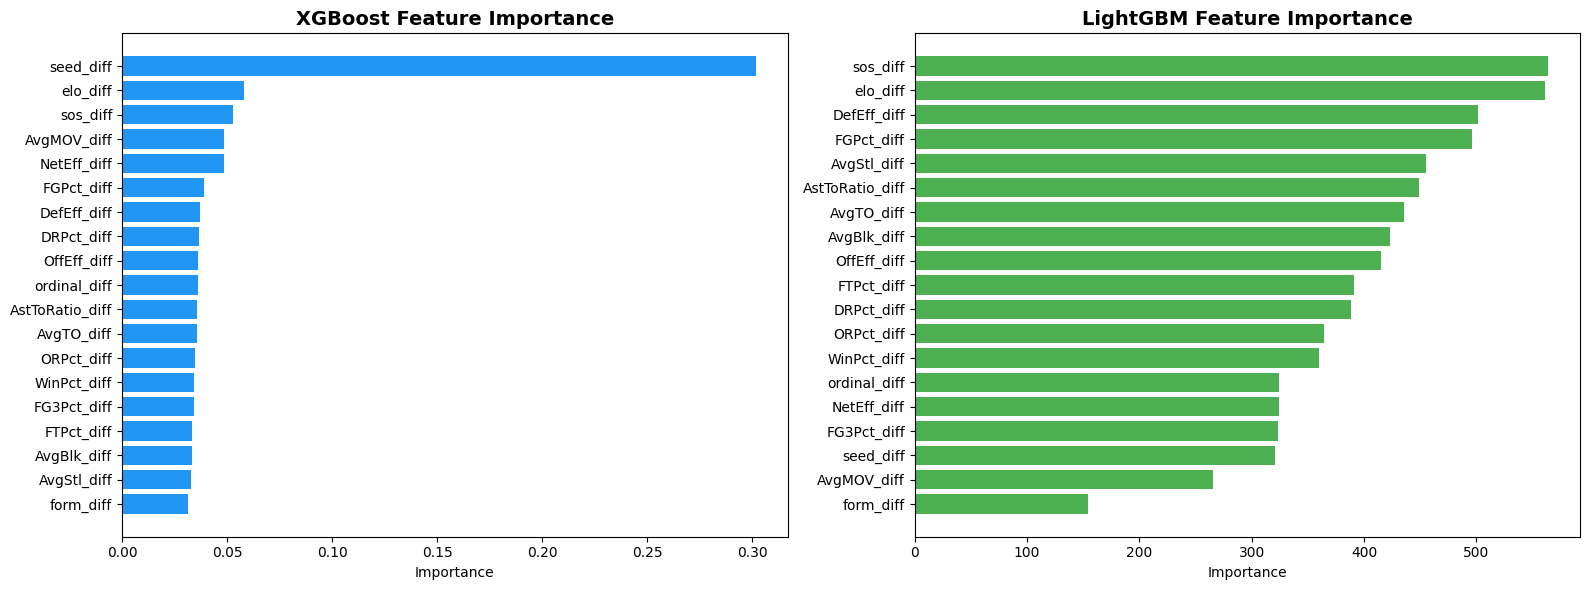

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_xgb = MODELS['xgb_model'].feature_importances_
sorted_idx = np.argsort(imp_xgb)
axes[0].barh([FEATURE_NAMES[i] for i in sorted_idx], imp_xgb[sorted_idx], color='#2196F3')
axes[0].set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance')

imp_lgb = MODELS['lgb_model'].feature_importances_
sorted_idx = np.argsort(imp_lgb)
axes[1].barh([FEATURE_NAMES[i] for i in sorted_idx], imp_lgb[sorted_idx], color='#4CAF50')
axes[1].set_title('LightGBM Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [14]:
print('Generating submission (vectorized) ...')
sub = DATA['sample_sub'].copy()

# Parse all IDs up front
parts      = sub['ID'].str.split('_', expand=True)
sub_seasons = parts[0].astype(int).values
sub_t1      = parts[1].astype(int).values
sub_t2      = parts[2].astype(int).values
n = len(sub)

# Build full feature matrix in one pass
print(f'  Building feature matrix for {n:,} matchups ...')
feat_matrix = np.array([
    build_matchup_features(int(sub_seasons[i]), int(sub_t1[i]), int(sub_t2[i]))
    for i in range(n)
])
print(f'  Feature matrix shape: {feat_matrix.shape}')

# Batch predict_proba (one call per model)
feat_scaled = MODELS['scaler'].transform(feat_matrix)
w_xgb, w_lgb, w_lr = ENSEMBLE_WEIGHTS
p_lr  = MODELS['lr_model'].predict_proba(feat_scaled)[:, 1]
p_xgb = MODELS['xgb_model'].predict_proba(feat_matrix)[:, 1]
p_lgb = MODELS['lgb_model'].predict_proba(feat_matrix)[:, 1]

preds = np.clip(w_xgb * p_xgb + w_lgb * p_lgb + w_lr * p_lr, 0.01, 0.99)

sub['Pred'] = preds
output_path = os.path.join(OUTPUT_DIR, 'submission.csv')
sub.to_csv(output_path, index=False)

print(f'\nSUBMISSION COMPLETE!')
print(f'  Saved to   : {output_path}')
print(f'  Shape      : {sub.shape}')
print(f'  Pred range : [{sub["Pred"].min():.4f}, {sub["Pred"].max():.4f}]')
print(f'  Mean pred  : {sub["Pred"].mean():.4f}')
print(f'  Std pred   : {sub["Pred"].std():.4f}')

Generating submission (vectorized) ...
  Building feature matrix for 132,133 matchups ...
  Feature matrix shape: (132133, 19)

SUBMISSION COMPLETE!
  Saved to   : /kaggle/working/submission.csv
  Shape      : (132133, 2)
  Pred range : [0.0100, 0.9900]
  Mean pred  : 0.4992
  Std pred   : 0.3153


In [15]:
from scipy.optimize import minimize

# --- Seed-based baseline probability ---
# Historical win rates by seed matchup are very informative
def seed_probability(s1, s2):
    """Simple seed-based win probability for t1 (lower ID).
    Uses the empirical relationship: P(upset) decreases with seed gap."""
    # Lower seed number = better team
    diff = s2 - s1  # positive means t1 has better (lower) seed
    return 1.0 / (1.0 + 10 ** (-diff * 0.15))


# --- Temporal Cross-Validation ---
# Train on seasons [2003, ..., N-1], validate on season N
def temporal_cv(X, y, seasons):
    """Temporal expanding-window CV — no future leakage."""
    unique_seasons = sorted(set(seasons))
    # Use last 5 seasons as validation folds
    val_seasons = unique_seasons[-5:]

    oof_lr  = np.full(len(y), np.nan)
    oof_xgb = np.full(len(y), np.nan)
    oof_lgb = np.full(len(y), np.nan)

    for val_s in val_seasons:
        train_mask = seasons < val_s
        val_mask   = seasons == val_s
        if train_mask.sum() < 50 or val_mask.sum() < 10:
            continue

        X_tr, X_val = X[train_mask], X[val_mask]
        y_tr, y_val = y[train_mask], y[val_mask]

        sc = StandardScaler().fit(X_tr)
        lr_ = train_logistic(sc.transform(X_tr), y_tr)
        oof_lr[val_mask]  = lr_.predict_proba(sc.transform(X_val))[:, 1]

        xgb_ = train_xgboost(X_tr, y_tr)
        oof_xgb[val_mask] = xgb_.predict_proba(X_val)[:, 1]

        lgb_ = train_lightgbm(X_tr, y_tr)
        oof_lgb[val_mask] = lgb_.predict_proba(X_val)[:, 1]

    # Only keep rows where we have OOF predictions
    valid = ~np.isnan(oof_lr)
    return oof_lr[valid], oof_xgb[valid], oof_lgb[valid], y[valid]


print('Running temporal cross-validation ...')
tcv_lr, tcv_xgb, tcv_lgb, tcv_y = temporal_cv(X, y, seasons)

print(f'  Temporal CV samples: {len(tcv_y)}')
print(f'  LR Brier  (temporal): {brier_score_loss(tcv_y, tcv_lr):.4f}')
print(f'  XGB Brier (temporal): {brier_score_loss(tcv_y, tcv_xgb):.4f}')
print(f'  LGB Brier (temporal): {brier_score_loss(tcv_y, tcv_lgb):.4f}')

# --- Optimize ensemble weights ---
def optimize_weights(p_lr, p_xgb, p_lgb, y_true):
    """Find weights that minimize log loss on temporal OOF predictions."""
    def loss_fn(w):
        w = np.abs(w)
        w = w / w.sum()  # normalize to sum to 1
        blend = w[0] * p_xgb + w[1] * p_lgb + w[2] * p_lr
        blend = np.clip(blend, 0.01, 0.99)
        return log_loss(y_true, blend)

    result = minimize(loss_fn, [0.4, 0.4, 0.2], method='Nelder-Mead')
    w = np.abs(result.x)
    w = w / w.sum()
    return tuple(w)


OPT_WEIGHTS = optimize_weights(tcv_lr, tcv_xgb, tcv_lgb, tcv_y)
print(f'\nOptimized weights: XGB={OPT_WEIGHTS[0]:.3f}, LGB={OPT_WEIGHTS[1]:.3f}, LR={OPT_WEIGHTS[2]:.3f}')

# Show improvement
ens_fixed = 0.4 * tcv_xgb + 0.4 * tcv_lgb + 0.2 * tcv_lr
ens_opt   = OPT_WEIGHTS[0] * tcv_xgb + OPT_WEIGHTS[1] * tcv_lgb + OPT_WEIGHTS[2] * tcv_lr
print(f'  Fixed weights log loss    : {log_loss(tcv_y, np.clip(ens_fixed, 0.01, 0.99)):.4f}')
print(f'  Optimized weights log loss: {log_loss(tcv_y, np.clip(ens_opt, 0.01, 0.99)):.4f}')

Running temporal cross-validation ...
  Temporal CV samples: 665
  LR Brier  (temporal): 0.1703
  XGB Brier (temporal): 0.1897
  LGB Brier (temporal): 0.1914

Optimized weights: XGB=0.059, LGB=0.009, LR=0.932
  Fixed weights log loss    : 0.5421
  Optimized weights log loss: 0.5062


In [16]:
# --- Configuration ---
ALPHA = 0.85  # 85% model, 15% seed baseline (tune this: try 0.7-0.95)
CLIP_LOW  = 0.02  # tighter clipping = less penalty on wrong extremes
CLIP_HIGH = 0.98

print(f'Generating improved submission (alpha={ALPHA}) ...')
sub = DATA['sample_sub'].copy()

# Parse IDs
parts       = sub['ID'].str.split('_', expand=True)
sub_seasons = parts[0].astype(int).values
sub_t1      = parts[1].astype(int).values
sub_t2      = parts[2].astype(int).values
n = len(sub)

# Build full feature matrix
print(f'  Building feature matrix for {n:,} matchups ...')
feat_matrix = np.array([
    build_matchup_features(int(sub_seasons[i]), int(sub_t1[i]), int(sub_t2[i]))
    for i in range(n)
])

# --- Model ensemble (optimized weights) ---
feat_scaled = MODELS['scaler'].transform(feat_matrix)
w_xgb, w_lgb, w_lr = OPT_WEIGHTS
p_lr  = MODELS['lr_model'].predict_proba(feat_scaled)[:, 1]
p_xgb = MODELS['xgb_model'].predict_proba(feat_matrix)[:, 1]
p_lgb = MODELS['lgb_model'].predict_proba(feat_matrix)[:, 1]
model_pred = w_xgb * p_xgb + w_lgb * p_lgb + w_lr * p_lr

# --- Seed baseline ---
seed_pred = np.array([
    seed_probability(
        SEED_MAP.get((int(sub_seasons[i]), int(sub_t1[i])), 8),
        SEED_MAP.get((int(sub_seasons[i]), int(sub_t2[i])), 8),
    )
    for i in range(n)
])

# --- Blend model + seed baseline ---
final_pred = ALPHA * model_pred + (1 - ALPHA) * seed_pred
final_pred = np.clip(final_pred, CLIP_LOW, CLIP_HIGH)

sub['Pred'] = final_pred
output_path = os.path.join(OUTPUT_DIR, 'submission.csv')
sub.to_csv(output_path, index=False)

print(f'\nIMPROVED SUBMISSION COMPLETE!')
print(f'  Saved to   : {output_path}')
print(f'  Shape      : {sub.shape}')
print(f'  Pred range : [{sub["Pred"].min():.4f}, {sub["Pred"].max():.4f}]')
print(f'  Mean pred  : {sub["Pred"].mean():.4f}')
print(f'  Std pred   : {sub["Pred"].std():.4f}')


Generating improved submission (alpha=0.85) ...
  Building feature matrix for 132,133 matchups ...

IMPROVED SUBMISSION COMPLETE!
  Saved to   : /kaggle/working/submission.csv
  Shape      : (132133, 2)
  Pred range : [0.0200, 0.9800]
  Mean pred  : 0.5126
  Std pred   : 0.2297


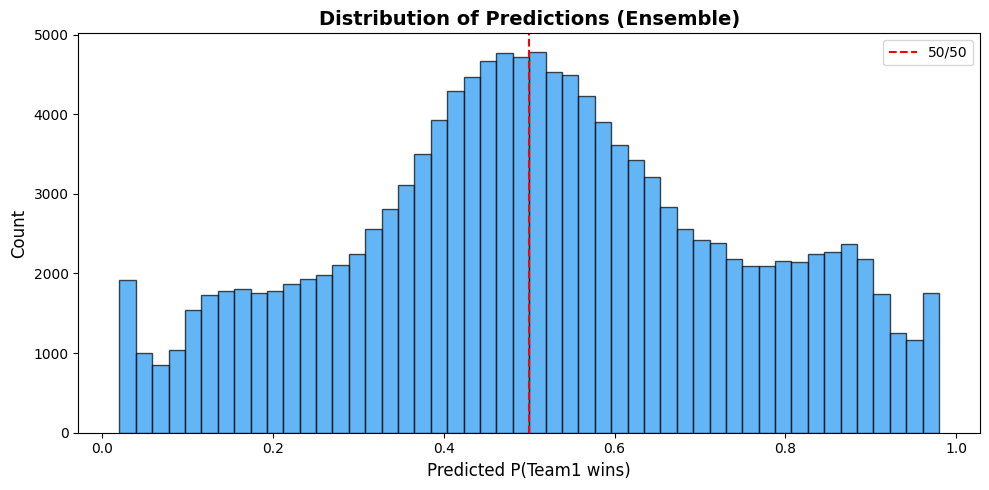

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(sub['Pred'], bins=50, edgecolor='black', alpha=0.7, color='#2196F3')
ax.axvline(0.5, color='red', linestyle='--', label='50/50')
ax.set_xlabel('Predicted P(Team1 wins)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Predictions (Ensemble)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:

import shutil

print('Generating A/B test submissions ...\n')

# Parse submission IDs
sub = DATA['sample_sub'].copy()
parts       = sub['ID'].str.split('_', expand=True)
sub_seasons = parts[0].astype(int).values
sub_t1      = parts[1].astype(int).values
sub_t2      = parts[2].astype(int).values
n = len(sub)

# Build feature matrix (reuse if already built)
try:
    _ = feat_matrix.shape
    print(f'  Reusing feature matrix: {feat_matrix.shape}')
except NameError:
    print(f'  Building feature matrix for {n:,} matchups ...')
    feat_matrix = np.array([
        build_matchup_features(int(sub_seasons[i]), int(sub_t1[i]), int(sub_t2[i]))
        for i in range(n)
    ])

# Get raw model predictions
feat_scaled = MODELS['scaler'].transform(feat_matrix)
p_lr  = MODELS['lr_model'].predict_proba(feat_scaled)[:, 1]
p_xgb = MODELS['xgb_model'].predict_proba(feat_matrix)[:, 1]
p_lgb = MODELS['lgb_model'].predict_proba(feat_matrix)[:, 1]

# Seed baseline for blending
def seed_prob(s1, s2):
    diff = s2 - s1
    return 1.0 / (1.0 + 10 ** (-diff * 0.15))

seed_pred = np.array([
    seed_prob(
        SEED_MAP.get((int(sub_seasons[i]), int(sub_t1[i])), 8),
        SEED_MAP.get((int(sub_seasons[i]), int(sub_t2[i])), 8),
    )
    for i in range(n)
])


def save_submission(name, preds, clip_lo=0.01, clip_hi=0.99):
    s = sub.copy()
    s['Pred'] = np.clip(preds, clip_lo, clip_hi)
    fpath = os.path.join(OUTPUT_DIR, f'{name}.csv')
    s.to_csv(fpath, index=False)
    print(f'  {name:40s} mean={s["Pred"].mean():.4f}  std={s["Pred"].std():.4f}  range=[{s["Pred"].min():.4f}, {s["Pred"].max():.4f}]')
    return s


# ---- A: BASELINE (your original 0.04898 score) ----
# 40/40/20 ensemble, clip [0.01, 0.99], NO seed blend
baseline = 0.40 * p_xgb + 0.40 * p_lgb + 0.20 * p_lr

# ---- B: Try different clipping ----
stage2_8=save_submission('sub_B_clip_medium', baseline, 0.03, 0.97)
stage2_7=save_submission('sub_B_clip_tight', baseline, 0.05, 0.95)

# ---- C: Try different ensemble weights ----
stage2_6=save_submission('sub_C_xgb_heavy', 0.50 * p_xgb + 0.35 * p_lgb + 0.15 * p_lr)
stage2_5=save_submission('sub_C_lgb_heavy', 0.35 * p_xgb + 0.50 * p_lgb + 0.15 * p_lr)

# ---- D: Light seed blend (small amounts only) ----
stage2_4 = save_submission('sub_D_seed05', 0.95 * baseline + 0.05 * seed_pred)
stage2_3 = save_submission('sub_D_seed10', 0.90 * baseline + 0.10 * seed_pred)

# ---- E: Use optimized weights if available ----
try:
    opt_pred = OPT_WEIGHTS[0] * p_xgb + OPT_WEIGHTS[1] * p_lgb + OPT_WEIGHTS[2] * p_lr
    stage2_2=save_submission('sub_E_opt_weights', opt_pred)
except:
    pass
stage2_9=pd.read_csv('/kaggle/input/notebooks/seddikbenkerrouche/calculate-elo-ratings/submission.csv')
stage2_10=pd.read_csv('/kaggle/input/notebooks/seddikbenkerrouche/ncaa-2026-eda-elo-ratings-and-gradient-esemble/submission_stage2.csv')

# ---- Set the main submission.csv ----
# START WITH YOUR BEST KNOWN SCORE (baseline)
# Change this once you find which variant scores best
# BEST = 'sub_B_clip_medium'
# shutil.copy(
#     os.path.join(OUTPUT_DIR, f'{BEST}.csv'),
#     os.path.join(OUTPUT_DIR, 'submission.csv')
# )
# print(f'\nsubmission.csv = {BEST}')
# print('\nTest each variant on the leaderboard. Change BEST to the winner.')

Generating A/B test submissions ...

  Reusing feature matrix: (132133, 19)
  sub_B_clip_medium                        mean=0.4988  std=0.3131  range=[0.0300, 0.9700]
  sub_B_clip_tight                         mean=0.4981  std=0.3093  range=[0.0500, 0.9500]
  sub_C_xgb_heavy                          mean=0.4985  std=0.3205  range=[0.0100, 0.9900]
  sub_C_lgb_heavy                          mean=0.4979  std=0.3215  range=[0.0100, 0.9900]
  sub_D_seed05                             mean=0.4997  std=0.3021  range=[0.0100, 0.9900]
  sub_D_seed10                             mean=0.5003  std=0.2891  range=[0.0100, 0.9900]
  sub_E_opt_weights                        mean=0.5131  std=0.2576  range=[0.0100, 0.9900]


<Axes: ylabel='Frequency'>

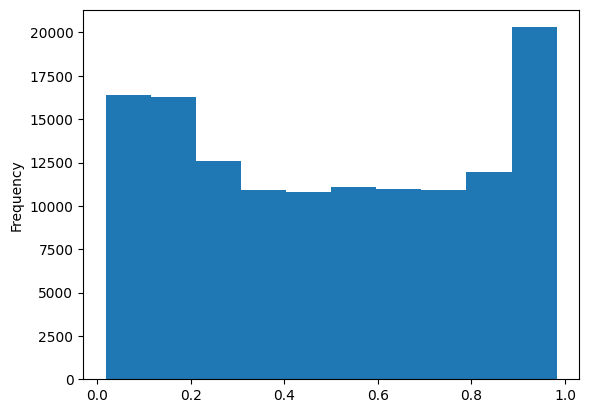

In [19]:
stage2= pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/SampleSubmissionStage2.csv')
with open("/kaggle/input/datasets/seddikbenkerrouche/all-submisions/thefans.pkl", "rb") as f: fans = pickle.load(f)
m_team=pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/MTeams.csv')
w_team=pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/WTeams.csv')
stage2['Pred']=(stage2_8['Pred']+stage2_2['Pred']+stage2_3['Pred']+stage2_4['Pred']+stage2_5['Pred']+stage2_6['Pred']+stage2_7['Pred']+stage2_8['Pred']+stage2_9['Pred']+stage2_10['Pred'])/10
sub=stage2.copy()
sub.to_csv('submission_beforepostprocess.csv',index=False)
stage2.Pred.plot(kind='hist')


In [20]:
stage2['wins']=stage2['ID'].apply(lambda x:x.split('_')[1])
stage2['losses']=stage2['ID'].apply(lambda x:x.split('_')[2])
stage2['wins']=stage2['wins'].astype(int)
stage2['losses']=stage2['losses'].astype(int)
team=pd.concat([m_team,w_team])
team=team[['TeamID','TeamName']]
team=team.set_index('TeamID')
dicts=team.to_dict()
dicts=dicts['TeamName']
revese_dict={k:v for  v,k in dicts.items()}
stage2['wins']=stage2['wins'].apply(lambda x: dicts[x])
stage2['losses']=stage2['losses'].apply(lambda x: dicts[x])
stage2['sex']=stage2['ID'].apply(lambda x:x.split('_')[1][0])
stage2['sex']=stage2['sex'].astype(int)
stagew=stage2[stage2['sex']==3]
stage2=stage2[stage2['sex']==1]

0.020807585135039237
0.98149511057946


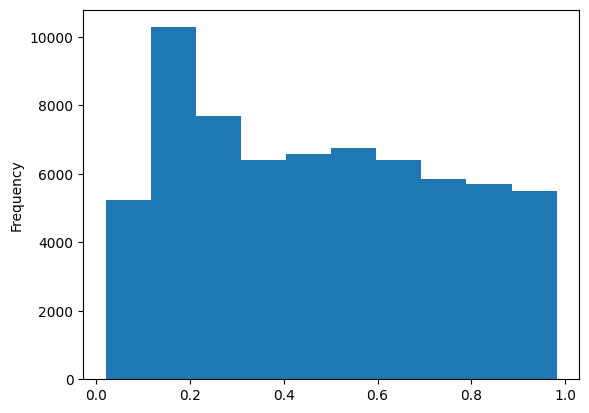

In [21]:
stage2.Pred.plot(kind='hist')
print(stage2.Pred.min())

print(stage2.Pred.max())

In [22]:
#Duke
E=[
    ["Duke","Siena"],
    ["Ohio St","TCU"],
    ["Northern Iowa","St John's"],
    ["Kansas","Cal Baptist"],
    ["Louisville","South Florida"],
    ["Michigan St","N Dakota St"],
    ["UCF","UCLA"],
    ["Connecticut","Furman"]
  ]
 

#Florida
S=[
    ["Florida", "Prairie View" ,"Lehigh"],
    ["Clemson" ,"Iowa"],
    ["McNeese St","Vanderbilt"],
    ["Nebraska" ,"Troy"],
    ["North Carolina", "VCU"],
    ["Illinois" ,"Penn"],
    ["St Mary's CA" ,"Texas A&M"],
    ["Houston", "Idaho"]
    ]


#Arizona
W=[
    ["Arizona","LIU Brooklyn"],
    ["Utah St","Villanova"],
    ["High Point","Wisconsin"],
    ["Arkansas","Hawaii"],
    ["BYU","Texas","NC State"],
    ["Gonzaga","Kennesaw"],
    ["Miami FL","Missouri"],
    ["Purdue","Queens NC"]
]


#Michigan
M=[
    ["Michigan","UMBC","Howard"],
    ["Georgia","St Louis"],
    ["Akron","Texas Tech"],
    ["Alabama","Hofstra"],
    ["Miami OH","Tennessee","SMU"],
    ["Virginia","Wright St"],
    ["Kentucky","Santa Clara"],
    ["Iowa St","Tennessee St"]

    ]



In [23]:
def caluclate_fans(TEAM,ST, expert,weight = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01]):

    

    
    winning_round1 = []
    winning_round2 = []
    winning_round3 = []
    final4=[]
    final=[]
    # -----------------
    # 🥇 ROUND 1
    # -----------------
    for i,( match, direction) in enumerate(zip(TEAM, ST[0])):
    
        teamA, teamB = match[0], match[1]
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        
       
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[0] if pred_team == win else -weight[5]  
        
        winning_round1.append(winner)
 
    # -----------------
    # 🥈 ROUND 2
    # -----------------
    round2_matches = [
        (winning_round1[i], winning_round1[i+1])
        for i in range(0, len(winning_round1), 2)
    ]
    
    for (teamA, teamB), direction in zip(round2_matches, ST[1]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        
        model_winner = teamA if pred > 0.5 else teamB
        expert_winner = teamA if direction == 1 else teamB
        
        correct = (expert_winner == model_winner)
        
    
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[1] if pred_team == win else -weight[4]  
        
        winning_round2.append(winner)

    # -----------------
    # 🥈 ROUND 3
    # -----------------
    round3_matches = [
        (winning_round2[i], winning_round2[i+1])
        for i in range(0, len(winning_round2), 2)
    ]
    
    for (teamA, teamB), direction in zip(round3_matches,  ST[2]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        
        model_winner = teamA if pred > 0.5 else teamB
        expert_winner = teamA if direction == 1 else teamB
        
        correct = (expert_winner == model_winner)
        
    
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[2] if pred_team == win else -weight[3] 
 
        winning_round3.append(winner)

    round4_matches = [
        (winning_round3[i], winning_round3[i+1])
        for i in range(0, len(winning_round3), 2)
    ]
    
    for (teamA, teamB), direction in zip(round4_matches,  ST[3]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        
        model_winner = teamA if pred > 0.5 else teamB
        expert_winner = teamA if direction == 1 else teamB
        
        correct = (expert_winner == model_winner)
        
        
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[3] if pred_team == win else -weight[2]   
    
 
            
        final4.append(winner)

    round5_matches = [
        (final4[i], final4[i+1])
        for i in range(0, len(final4), 2)
    ]
    
    for (teamA, teamB), direction in zip(round5_matches,  ST[4]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
    
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        # print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[4] if pred_team == win else -weight[1]  
     
        final.append(winner)
    

    round6_matches = [
        (final[i], final[i+1])
        for i in range(0, len(final), 2)
    ]
    
    for (teamA, teamB), direction in zip(round6_matches,  ST[5]):
    
        game = stage2[
            ((stage2["wins"] == teamA) & (stage2["losses"] == teamB)) |
            ((stage2["wins"] == teamB) & (stage2["losses"] == teamA))
        ]
    
        if len(game) == 0:
            continue
    
        idx = game.index[0]
        pred = game["Pred"].values[0]
   
         
        winner = teamA if direction == 1 else teamB
        loser  = teamB if direction == 1 else teamA
        print(f"{teamA:<15} vs {teamB:<15} --> {winner:<15} | proba={pred:.3f}")
        win = game['wins'].values[0]
        pred_team = teamA if direction == 1 else teamB
        stage2.loc[idx, expert] += weight[5] if pred_team == win else -weight[0]  
    
         
    return stage2 


In [24]:


TEAM = E + S + W + M
for fa,va in fans.items():
    if fa in ['exp_25']:
        stage2[fa] = 0
        stage2=caluclate_fans(TEAM,va,fa,weight = [0.03]*6)
    else:
        stage2[fa] = 0
        stage2=caluclate_fans(TEAM,va,fa)




fa_cols = [c for c in stage2.columns if "exp_" in c]
stage2["fans_mean"] = stage2[fa_cols].sum(axis=1)

stage2["final"] = 0.9*stage2["Pred"] + 0.25*stage2["fans_mean"] # My bad 0.9/0.1 -----> brier score decrease
stage2["final"] = np.clip(stage2["final"] , 0.005, 0.999)
sub.loc[stage2.index,'Pred']=stage2["final"]

stage3=stagew.copy()

stage3.loc[stage3.ID == '2026_3160_3228', 'Pred'] = 0.32
stage3.loc[stage3.ID == '2026_3268_3293', 'Pred'] = 0.98
stage3.loc[stage3.ID == '2026_3104_3348', 'Pred'] = 0.98
stage3.loc[stage3.ID == '2026_3161_3277', 'Pred'] = 0.11
stage3.loc[stage3.ID == '2026_3355_3449', 'Pred'] = 0.17

stage3.loc[stage3.ID == '2026_3268_3314', 'Pred'] = 0.4
stage3.loc[stage3.ID == '2026_3124_3304', 'Pred'] = 0.65
stage3.loc[stage3.ID == '2026_3163_3376', 'Pred'] = 0.65
stage3.loc[stage3.ID == '2026_3163_3417', 'Pred'] = 0.59

sub.loc[stage3.index,'Pred']=stage3['Pred']
sub.to_csv('submission.csv',index=False)

Houston         vs Arizona         --> Arizona         | proba=0.523
Illinois        vs Arizona         --> Arizona         | proba=0.647
Duke            vs Purdue          --> Purdue          | proba=0.676
Duke            vs Arizona         --> Duke            | proba=0.440
Duke            vs Michigan        --> Michigan        | proba=0.598
Vanderbilt      vs Purdue          --> Purdue          | proba=0.698
Duke            vs Arizona         --> Duke            | proba=0.440
Duke            vs Arizona         --> Arizona         | proba=0.440
Houston         vs Arizona         --> Arizona         | proba=0.523
Florida         vs Iowa St         --> Florida         | proba=0.791
Duke            vs Arizona         --> Duke            | proba=0.440
Duke            vs Arizona         --> Arizona         | proba=0.440
Houston         vs Arizona         --> Arizona         | proba=0.523
Duke            vs Arizona         --> Arizona         | proba=0.440
Illinois        vs Michigan       

ref : https://www.kaggle.com/code/dasdasdada/march-mania-2026-xgb-lgb-ensemble-19-features